<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Class%2011%20/%20class11_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Environment Initialization and Data Ingestion

In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

df = pd.read_csv('messy_hr_economics.csv')
df.head()

,employee_id,department_raw,department,office_zip,tenure_years,age,year_hired,regional_unemployment,regional_cpi_inflation,performance_rating,bonus_pay,base_salary,retention_risk
0,E100000,Sls,Sales,91586,2.3,27,2024,4.30,3.54,3.0,3571.89,64113.01,0.275
1,E100001,ENG.,Engineering,70260,2.2,38,2024,3.52,3.95,4.5,9351.25,113883.39,0.196
2,E100002,Sales,Sales,33731,1.2,44,2025,4.38,0.70,2.5,3046.72,NaN,0.333
3,E100003,SLS.,Sales,62903,3.2,31,2023,6.59,3.10,NaN,NaN,58762.73,0.222
4,E100004,ENG.,Engineering,85512,7.6,40,2019,6.33,2.99,3.5,8669.21,108171.29,0.189


Step 2: Visual Forensics of Missing Data

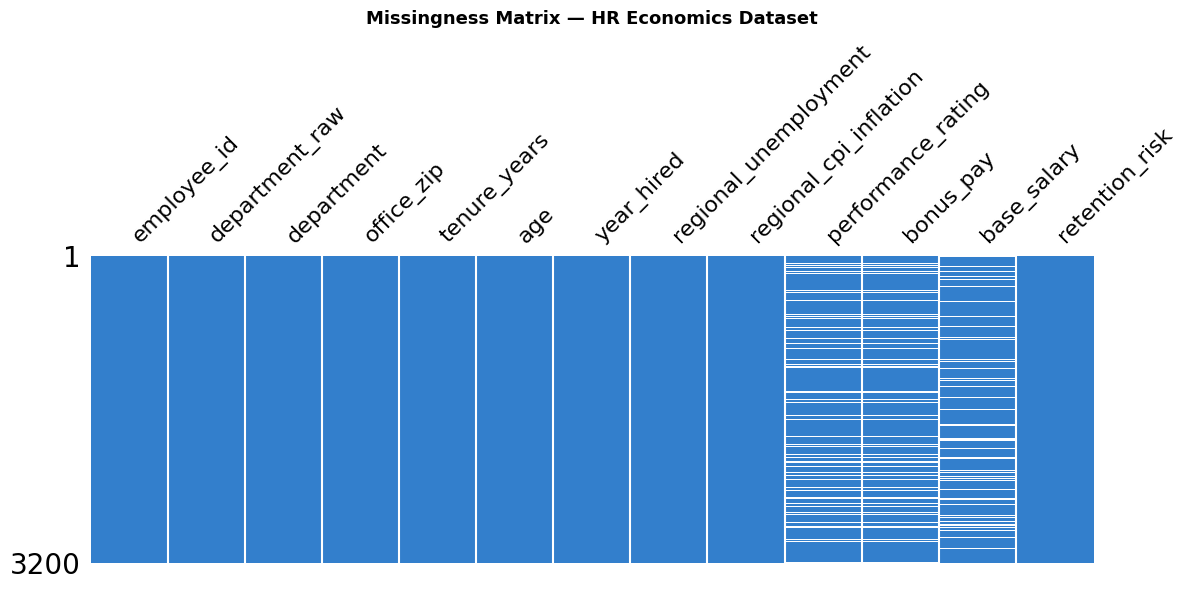

In [7]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df, figsize=(12, 6), sparkline=False, color=(0.2, 0.5, 0.8))
plt.title("Missingness Matrix — HR Economics Dataset", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Step 3: Handling the Missingness via Conditional Imputation

In [10]:
# conduct imputation with median of the other base salaries in the given dept
df['base_salary'] = df.groupby('department')['base_salary'].transform(lambda x: x.fillna(x.median()))

In [11]:
# Verify no residual missingness and distribution is preserved
print(df['base_salary'].isnull().sum())  # should be 0
df.groupby('department')['base_salary'].agg(['mean', 'median', 'std'])

0


,mean,median,std
department,,,
Engineering,109906.983216,108666.880,15338.466233
Marketing,84005.181761,83365.265,12714.600451
Sales,80933.967525,80097.170,12813.954333


Step 4: Springing the Dummy Variable Trap

In [13]:
# Step 4: The Dummy Variable Trap (Intentional Failure)
dummies_trap = pd.get_dummies(df['department'], prefix='dept').astype(int)
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)

# Adding the constant intercept creates perfect multicollinearity
X_trap = sm.add_constant(X_trap)
y = df['base_salary']

# This will trigger a severe multicollinearity warning or a LinAlgError
model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:11:32   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.765e+04    244.020  

Step 5: Escaping the Trap and Executing Advanced Encoding

In [14]:
# Step 5: Escaping the Trap (k-1 methodology)
# drop_first=True establishes the reference category
dummies_safe = pd.get_dummies(df['department'], prefix='dept', drop_first=True).astype(int)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Condensing 800 ZIP codes into a single continuous vector representing average salary
encoder = ce.TargetEncoder()
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:13:23   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9.527e+04    372.412    255.

AI Assisted Expansion (just code as Streamlit can't be run from jupyter notebook or google colab)

Code added to app.py file and launched using the following commands:
```
pip install streamlit missingno category_encoders
streamlit run app.py
```

In [ ]:
import streamlit as st
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import io

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(page_title="Missing Data Auditor", layout="wide")
st.title("🔍 Missing Data Auditor")
st.caption("Upload a CSV to diagnose missingness and apply conditional median imputation.")

# ── Caching ───────────────────────────────────────────────────────────────────
# @st.cache_data memoizes the function output keyed on its arguments.
# Streamlit hashes the uploaded file bytes — if the same file is re-uploaded,
# the cached DataFrame is returned instantly instead of re-parsing. This
# prevents redundant computation on every UI interaction (slider move, button
# click, etc.) that triggers a full script re-run.
@st.cache_data
def load_data(uploaded_file) -> pd.DataFrame:
    return pd.read_csv(uploaded_file)


# ── Session State ─────────────────────────────────────────────────────────────
# st.session_state is a dictionary that persists across re-runs within the same
# browser session. Unlike regular Python variables (which reset on every re-run),
# session_state retains values. We use it to hold:
#   - 'df':       the working DataFrame (mutated by imputation in-place)
#   - 'imputed':  a boolean flag so the UI can reflect whether imputation ran
if "df" not in st.session_state:
    st.session_state.df = None
if "imputed" not in st.session_state:
    st.session_state.imputed = False

# ── Sidebar: Upload ───────────────────────────────────────────────────────────
with st.sidebar:
    st.header("1. Upload Dataset")
    uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

    if uploaded_file:
        # Load via cached function; store in session_state so downstream
        # widgets can mutate it without losing state on re-run.
        st.session_state.df = load_data(uploaded_file).copy()
        st.session_state.imputed = False  # reset flag on new upload
        st.success(f"Loaded {len(st.session_state.df):,} rows")

    st.divider()
    st.header("2. Imputation Settings")
    st.caption("Select the target column and grouping column for conditional median imputation.")

# ── Main content ──────────────────────────────────────────────────────────────
if st.session_state.df is None:
    st.info("⬅️ Upload a CSV file from the sidebar to begin.")
    st.stop()

df = st.session_state.df

# ── Section 1: Raw data preview ───────────────────────────────────────────────
with st.expander("📄 Raw Data Preview", expanded=False):
    st.dataframe(df.head(50), use_container_width=True)

# ── Section 2: Missingness summary table ─────────────────────────────────────
st.subheader("Missing Value Summary")
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %":     (df.isnull().mean() * 100).round(2)
}).query("`Missing Count` > 0").sort_values("Missing Count", ascending=False)

if missing_summary.empty:
    st.success("✅ No missing values detected.")
else:
    st.dataframe(missing_summary, use_container_width=True)

# ── Section 3: Missingness matrix ────────────────────────────────────────────
st.subheader("Missingness Matrix")
st.caption(
    "White gaps indicate missing values. Vertically aligned gaps across columns "
    "signal **MAR** — the missingness in one column is structurally dependent on another."
)

fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df, ax=ax, sparkline=False, color=(0.2, 0.5, 0.8))
ax.set_title("Missingness Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()

# Render matplotlib figure into Streamlit via BytesIO buffer
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
buf.seek(0)
st.image(buf, use_column_width=True)
plt.close(fig)

# ── Section 4: Conditional median imputation ─────────────────────────────────
st.subheader("Conditional Median Imputation")

# Identify imputable columns (numeric with nulls) and categorical grouping columns
numeric_cols_with_nulls = [
    c for c in df.select_dtypes(include="number").columns if df[c].isnull().any()
]
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

if not numeric_cols_with_nulls:
    st.info("No numeric columns with missing values — nothing to impute.")
    st.stop()

col1, col2 = st.columns(2)
with col1:
    target_col = st.selectbox(
        "Target column (numeric, has nulls)",
        options=numeric_cols_with_nulls
    )
with col2:
    group_col = st.selectbox(
        "Group-by column (categorical)",
        options=categorical_cols
    )

# Show pre-imputation group medians for transparency
with st.expander("📊 Pre-Imputation Group Medians", expanded=False):
    group_medians = df.groupby(group_col)[target_col].median().reset_index()
    group_medians.columns = [group_col, f"Median {target_col}"]
    st.dataframe(group_medians, use_container_width=True)

# Imputation button
if st.button("▶ Run Conditional Median Imputation", type="primary"):
    before_nulls = df[target_col].isnull().sum()

    # Grouped transform: each group's median is broadcast back to original index.
    # fillna only touches NaN positions — observed values are unchanged.
    st.session_state.df[target_col] = (
        st.session_state.df
        .groupby(group_col)[target_col]
        .transform(lambda x: x.fillna(x.median()))
    )

    after_nulls = st.session_state.df[target_col].isnull().sum()
    st.session_state.imputed = True

    st.success(
        f"✅ Imputed **{before_nulls - after_nulls}** missing values in `{target_col}` "
        f"using group medians from `{group_col}`. Residual nulls: {after_nulls}."
    )

# ── Section 5: Post-imputation state ─────────────────────────────────────────
if st.session_state.imputed:
    st.subheader("Post-Imputation Missingness Matrix")
    fig2, ax2 = plt.subplots(figsize=(12, 5))
    msno.matrix(st.session_state.df, ax=ax2, sparkline=False, color=(0.1, 0.7, 0.4))
    ax2.set_title("Missingness Matrix (Post-Imputation)", fontsize=12, fontweight="bold")
    plt.tight_layout()

    buf2 = io.BytesIO()
    fig2.savefig(buf2, format="png", dpi=130, bbox_inches="tight")
    buf2.seek(0)
    st.image(buf2, use_column_width=True)
    plt.close(fig2)

    st.subheader("Download Imputed Dataset")
    csv_out = st.session_state.df.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️ Download CSV",
        data=csv_out,
        file_name="imputed_dataset.csv",
        mime="text/csv"
    )